In [1]:
from bs4 import BeautifulSoup
import copy
import json
import numpy as np
import os
from PIL import Image

In [2]:
edition_directory = "./KuiSCIMA/optical_symbolic_dataset/05_shanghai_manuscript/"

In [3]:
class Line:
    def __init__(self, boxes: list):
        self.boxes = boxes

    def __len__(self):
        return len(self.boxes)

    def __iter__(self):
        return iter(self.boxes)

    def __getitem__(self, idx: int):
        return self.boxes[idx]

    def __delitem__(self, idx: int):
        del self.boxes[idx]

    def append(self, item):
        self.boxes.append(item)
        
class TextLine(Line):
    def __repr__(self):
        return f"TextLine({"".join([box["text_content"] for box in self.boxes])})"

    def coordinates(self):
        x_min = np.inf
        x_max = 0
        y_min = np.inf
        y_max = 0
        
        for box in self.boxes:
            (x1, y1), (x2, y2) = box["text_coordinates"]
            x_min = min(x1, x2, x_min)
            x_max = max(x1, x2, x_max)
            y_min = min(y1, y2, y_min)
            y_max = max(y1, y2, y_max)

        return ((x_min, y_min), (x_max, y_max))

    def page(self):
        return self.boxes[0]["text_page"]
        

class LyricsLine(Line):
    def __repr__(self):
        return f"LyricsLine({"".join([box["text_content"] for box in self.boxes])})"

    def coordinates(self):
        x_min = np.inf
        x_max = 0
        y_min = np.inf
        y_max = 0
        
        for box in self.boxes:
            (x1, y1), (x2, y2) = box["text_coordinates"]
            x_min = min(x1, x2, x_min)
            x_max = max(x1, x2, x_max)
            y_min = min(y1, y2, y_min)
            y_max = max(y1, y2, y_max)

        return ((x_min, y_min), (x_max, y_max))

    def page(self):
        return self.boxes[0]["text_page"]

class MusicLine(Line):
    def __repr__(self):
        return f"MusicLine({"".join(["*" for box in self.boxes])})"

    def coordinates(self):
        x_min = np.inf
        x_max = 0
        y_min = np.inf
        y_max = 0
        
        for box in self.boxes:
            (x1, y1), (x2, y2) = box["notation_coordinates"]
            x_min = min(x1, x2, x_min)
            x_max = max(x1, x2, x_max)
            y_min = min(y1, y2, y_min)
            y_max = max(y1, y2, y_max)

        return ((x_min, y_min), (x_max, y_max))

    def page(self):
        return self.boxes[0]["notation_page"]

class CombinedLine:
    def __init__(self, notation_boxes, lyrics_boxes):
        self.notation_boxes = notation_boxes
        self.lyrics_boxes = lyrics_boxes

    def __repr__(self):
        return f"CombinedLine({"".join(["*" for box in self.notation_boxes])}{"".join([box["text_content"] for box in self.lyrics_boxes])})"

In [25]:
def transform_coordinates(box, images):
    (x, y), (x2, y2) = box
    offset = 0
    for page_idx, page in enumerate(images[::-1]):  # pages are read from right to left
        offset += page.width
        if x < offset:
            break
    
    correct_page_idx = len(images)-1-page_idx
    x_offset = offset-page.width

    return correct_page_idx, ((x-x_offset, y), (x2-x_offset, y2))

def segment_boxes_into_lines(boxes: list, images: list[Image]):
    # Raw lines treat music lines (consisting of one notation line and
    # one lyrics line) as one line.

    raw_lines = []
    for box in boxes:
        if "notation_coordinates" in box and box["notation_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["notation_coordinates"], images)
            box["notation_coordinates"] = new_box
            box["notation_page"] = os.path.basename(images[page_idx].filename)
        if "text_coordinates" in box and box["text_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["text_coordinates"], images)
            box["text_coordinates"] = new_box
            box["text_page"] = os.path.basename(images[page_idx].filename)
        if len(raw_lines) == 0 or raw_lines[-1][-1]["is_line_break"]:
            raw_lines.append([box])
        else:
            raw_lines[-1].append(box)
        

    lines = []
    for line in raw_lines:
        line_types = set([box["box_type"] for box in line])
        if len(line_types) == 1 and "Music" in line_types:
            if line[0]["notation_content"] is not None:
                lines.append(MusicLine(copy.deepcopy(line)))
            if line[0]["text_content"] is not None:
                lines.append(LyricsLine(copy.deepcopy(line)))
        elif "Music" not in line_types:
            lines.append(TextLine(copy.deepcopy(line)))
        else:
            print("WARNING:", line_types)
            print("".join([box["text_content"] for box in line]))
            
    return lines

        
def segment_into_blocks(boxes):
    """
    Group boxes of same box type together. We need this so we can choose the boundaries of the
    TEI components correctly, e.g. <head> enclosing the title boxes, etc.

    Also, the music boxes contain two positions each: The right side contains the musical notation,
    while the left side contains the lyric character. To correctly encode this, we need to split the
    data accordingly.

    For this, we need column break information to determine the position of each box correctly!
    """
    boxes = copy.deepcopy(boxes)
    blocks = []
    for box in boxes:
        # i)   If there are no blocks yet, make a new block.
        # ii)  If there is a block but the current box' type is different
        #      than the current block's type, make a new block.
        if len(blocks) and blocks[-1][-1]["box_type"] == box["box_type"]:
            blocks[-1].append(box)
        else:
            blocks.append([box])
    return blocks
    
def add_block_tags(blocks):
    blocks = copy.deepcopy(blocks)
    for block in blocks:
        block_type = block[0]["box_type"]
        if block_type == "Title":  # titles are <head>
            block[0]["text_content"] = "<head><title>" + block[0]["text_content"]
            block[-1]["text_content"] += "</title></head>"
        elif block_type == "Preface":
            block[0]["text_content"] = '<p ana="preface">' + block[0]["text_content"]
            block[-1]["text_content"] += "</p>"
        elif block_type == "Mode":
            block[0]["text_content"] = '<p ana="mode" rend="small">' + block[0]["text_content"]
            block[-1]["text_content"] += "</p>"
        elif block_type == "Music":
            block[0]["text_content"] = '<lg><l>' + block[0]["text_content"]
            block[-1]["text_content"] += "</l></lg>"
    return blocks

In [76]:
class JsonBased:
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
            self.boxes = self.json["content"]
            self.image_files = self.json["images"]
            self.file = os.path.basename(file_path)
            images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
            self.physical_lines = segment_boxes_into_lines(self.boxes, images)

class Song(JsonBased):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

    def __str__(self):
        return f"Song({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""
        for line in self.lines:
            tei_string += "".join([box["text_content"] for box in line]) + "\n"

        return f'<div type="song">{tei_string}</div>'

class SongOfYue(JsonBased):
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
            self.boxes = self.json["content"]
            # Songs of Yue have special structure regarding their content.
            # The title (plus an indication that the piece is to the right)
            # is found after the music and lyrics!
            title_boxes = [box for box in self.boxes if box["box_type"] in ("Unmarked", "Title")]
            music_boxes = [box for box in self.boxes if box["box_type"] not in ("Unmarked", "Title", "Mode")]
            mode_boxes = [box for box in self.boxes if box["box_type"] == "Mode"]
            self.boxes = music_boxes + title_boxes + mode_boxes
            self.image_files = self.json["images"]
            self.file = os.path.basename(file_path)
            images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
            self.physical_lines = segment_boxes_into_lines(self.boxes, images)

            self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

            # Update logical lines
            self.logical_lines = [[CombinedLine([], [])]]
            for notation_box, lyric_box in zip([box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)], [box for line in self.physical_lines for box in line if isinstance(line, MusicLine)]):
                if lyric_box["text_content"] in (None, "", " "):
                    self.logical_lines.append([CombinedLine([], [])])
                elif lyric_box["is_line_break"]:
                    self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                    self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
                    self.logical_lines[-1] += [CombinedLine([], [])]
                else:
                    self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                    self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
            del self.logical_lines[-1][-1]

            # There are additional logical line break boxes that should be removed
            for line in self.physical_lines:
                if line[-1]["text_content"] in (None, "", " "):
                    del line[-1]

            # Update boxes accordingly
            self.boxes = [box for line in self.physical_lines for box in line]

    def __str__(self):
        return f"SongOfYue({self.title}, {self.file})"

    def to_tei(self):
        tei_string = ""
        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for physical_line in line:
                if "tei_pb" in physical_line.notation_boxes[0]:
                    tei_string += f'<pb facs="#{physical_line.notation_boxes[0]["tei_pb"]}"/>'
                if "tei_lb" in physical_line.notation_boxes[0]:
                    tei_string += f'<lb facs="#{physical_line.notation_boxes[0]["tei_lb"]}"/>'
                tei_string += "<notatedMusic/>"

                if "tei_pb" in physical_line.lyrics_boxes[0]:
                    tei_string += f'<pb facs="#{physical_line.lyrics_boxes[0]["tei_pb"]}"/>'
                if "tei_lb" in physical_line.lyrics_boxes[0]:
                    tei_string += f'<lb facs="#{physical_line.lyrics_boxes[0]["tei_lb"]}"/>'
                    
                for box in physical_line.lyrics_boxes:
                    tei_string += box["text_content"]
            tei_string += "</l>"
        tei_string += "</lg>"

        # title and mode
        title_and_mode_line = self.physical_lines[-1]
        tei_string += "<trailer>"
        if "tei_pb" in title_and_mode_line[0]:
            tei_string += f'<pb facs="#{title_and_mode_line[0]["tei_pb"]}"/>'
        if "tei_lb" in title_and_mode_line[0]:
            tei_string += f'<lb facs="#{title_and_mode_line[0]["tei_lb"]}"/>'
        tei_string += title_and_mode_line[0]["text_content"]
        tei_string += "<title>"
        for box in title_and_mode_line:
            if box["box_type"] == "Title":
                tei_string += box["text_content"]
        tei_string += "</title>"

        if "Mode" in [box["box_type"] for box in title_and_mode_line]:
            tei_string += '<space quantity="2" unit="chars"/><seg type="mode">'
            for box in title_and_mode_line:
                if box["box_type"] == "Mode":
                    tei_string += box["text_content"]
            tei_string += "</seg>"
        tei_string += "</trailer>"

        return f'<div type="song">{tei_string}</div>'
                
            
#print(Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/01_shangdiming.json").physical_lines)
#print(Song(edition_directory + "./json/02_qinquyishou/015_guyuan.json").physical_lines)
#print(SongOfYue(edition_directory + "./json/03_yuejiuge/016_dishunchudiao.json").to_tei())
print(SongOfYue(edition_directory + "./json/03_yuejiuge/021_taozhishenshuangdiao.json").to_tei())
#print(Song(edition_directory + "./json/04_ling/026_xiaochongshanling.json").physical_lines)
#print(Song(edition_directory + "./json/05_man/059_nishangzhongxu.json").physical_lines)
#print(Song(edition_directory + "./json/06_ziduqu/079_yangzhouman.json").physical_lines)
#print(Song(edition_directory + "./json/07_zizhiqu/088_quixiaoyin.json").physical_lines)
#print(Song(edition_directory + "./json/08_bieji/092_xiaochongshanling.json").physical_lines)

<div type="song"><lg><l><notatedMusic/>海門碧𠔃崔嵬潬上去𠔃潬下來予乗舟𠔃遲女目屢<notatedMusic/>眩𠔃漚飛</l><l><notatedMusic/>白馬駃𠔃素縿舞驅銀山𠔃疊萬鼓汨予從天𠔃南逝<notatedMusic/>經西陵𠔃掠漁浦</l><l><notatedMusic/>夫在舶𠔃婦在房風浩浩𠔃波茫茫𤁋予酒𠔃神龍府<notatedMusic/>我征至𠔃無所苦</l></lg><trailer>右<title>濤之神雙調</title></trailer></div>


In [97]:

class Table:
    def __init__(self, file_path: str):
        pass


class Description:
    def __init__(self, file_path: str):
        pass


class Section:
    def __init__(self, information_file: str, children: list[Description | Table | Song]):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
            self.information_boxes = self.information_json["content"]
            self.information_boxes = [box for box in self.information_boxes if box["box_type"] in ("Title", "Preface")]

        self.children = children

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        for child in children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set(self.information_json["images"] +
                               [file for child in self.children for file in child.image_files])
        self.boxes = (self.information_boxes + [box for child in self.children for box in child.boxes])
        self.file = os.path.basename(information_file)
        self.title = "".join([box["text_content"] for box in self.information_boxes if box["box_type"] == "Title"])
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Section({self.title}, {self.file})\n"
        for child in self.children:
            return_string += f"    {child}\n"
        return_string = return_string[:-1]
        return return_string
    
    def to_tei(self):
        preface_boxes = [box for box in self.information_boxes if box["box_type"] == "Preface"]

        tei_string = ""
        if len(preface_boxes):
            tei_string += '<p ana="preface">'
            for line in self.physical_lines:
                if line[0]["box_type"] == "Preface":
                    if "tei_pb" in line[0]:
                        tei_string += f'<pb facs="#{line[0]["tei_pb"]}"/>'
                    if "tei_lb" in line[0]:
                        tei_string += f'<lb facs="#{line[0]["tei_lb"]}"/>'
                    if line[0]["box_type"] == "Preface":
                        preface_line = "".join([box["text_content"] for box in line])
                        tei_string += preface_line
            tei_string += "</p>"
        
        for child in self.children:
            tei_string += child.to_tei()

        title = ""
        if "tei_pb" in self.information_boxes[0]:
            title += f'<pb facs="#{self.information_boxes[0]["tei_pb"]}"/>'
        if "tei_lb" in self.information_boxes[0]:
            title += f'<lb facs="#{self.information_boxes[0]["tei_lb"]}"/>'
        for box in self.information_boxes:
            if box["box_type"] == "Title":
                title += box["text_content"]
        return f'<div type="section"><head>{title}</head>{tei_string}</div>'

    
class Juan:
    def __init__(self, information_file: str, children: list[Section]):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
            self.information_boxes = self.information_json["content"]
            self.information_boxes = [box for box in self.information_boxes if box["box_type"] == "Unmarked"]

        self.children = children

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        for child in children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set(self.information_json["images"] +
                               [file for child in self.children for file in child.image_files])
        self.boxes = (self.information_boxes + [box for child in self.children for box in child.boxes])
        self.title = "".join([box["text_content"] for box in self.information_boxes])
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Juan({self.title})\n"
        for child in self.children:
            child_string = str(child).split("\n")
            child_string = "".join(["    "+string+"\n" for string in child_string])
            return_string += f"{child_string}"
        return_string = return_string[:-1]
        return return_string
    
    def to_tei(self):
        tei_string = ""

        title = ""
        if "tei_pb" in self.information_boxes[0]:
            tei_string += f'<pb facs="#{self.information_boxes[0]["tei_pb"]}"/>'
        if "tei_lb" in self.information_boxes[0]:
            tei_string += f'<lb facs="#{self.information_boxes[0]["tei_lb"]}"/>'
        for box in self.information_boxes:
            title += box["text_content"]
        
            
        for child in self.children:
            tei_string += child.to_tei()
        # Juan always start with page break
        return f'<div type="juan"><head>{title}</head>{tei_string}</div>'

class TableOfContents:
    def __init__(self, file_path: str):
        pass


class Book:
    def __init__(self, children: list[TableOfContents | Juan | Section]):
        self.children = children

        self.physical_lines = []
        for child in children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set([file for child in self.children for file in child.image_files])
        self.boxes = [box for child in self.children for box in child.boxes]
        
        # assign facsimile data
        page_groups = []
        for line in self.physical_lines:
            if len(page_groups) == 0 or line.page() != page_groups[-1][-1].page():
                page_groups.append([line])
            else:
                page_groups[-1].append(line)

        self.facsimile = "<facsimile>"

        line_idx = 1
        for group in page_groups:
            page_id = group[0].page().split(".")[0]
            self.facsimile += f'<surface xml:id="{page_id}">'
            group[0][0]["tei_pb"] = page_id
            self.facsimile += f'<graphic url="images/{group[0].page()}"/>'
            for line in group:
                (ulx, uly), (lrx, lry) = line.coordinates()
                line_id = f"line_{line_idx:04d}"
                line[0]["tei_lb"] = line_id
                self.facsimile += f'<zone ulx="{ulx}" uly="{uly}" lrx="{lrx}" lry="{lry}" xml:id="{line_id}"/>'
                line_idx += 1
            self.facsimile += "</surface>"
                    
        self.facsimile += "</facsimile>"
        
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Book(\n"
        for child in self.children:
            child_string = str(child).split("\n")
            child_string = "".join(["    "+string+"\n" for string in child_string])
            return_string += f"{child_string}"
        return_string = return_string[:-1] + "\n)"
        return return_string
    
    def to_tei(self):
        text_string = ""
        for child in self.children:
            text_string += child.to_tei()

        self.header = "<teiHeader><fileDesc><titleStmt><title>Title</title></titleStmt><publicationStmt><p>Publication Information</p></publicationStmt><sourceDesc><p>Information about the source</p></sourceDesc></fileDesc></teiHeader>"
        
        output_string =  '<?xml version="1.0" encoding="UTF-8"?>'
        output_string += '<?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?>'
        output_string += '<?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?>'
        output_string += f'<TEI xmlns="http://www.tei-c.org/ns/1.0">{self.header}{self.facsimile}<text><body><div type="book">{text_string}</div></body></text></TEI>'
        return output_string

<?xml version="1.0" encoding="UTF-8"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?><TEI xmlns="http://www.tei-c.org/ns/1.0"><teiHeader><fileDesc><titleStmt><title>Title</title></titleStmt><publicationStmt><p>Publication Information</p></publicationStmt><sourceDesc><p>Information about the source</p></sourceDesc></fileDesc></teiHeader><facsimile><surface xml:id="shanghai_manuscript_021"><graphic url="images/shanghai_manuscript_021.png"/><zone ulx="717" uly="18" lrx="787" lry="482" xml:id="line_0001"/><zone ulx="644" uly="60" lrx="708" lry="228" xml:id="line_0002"/><zone ulx="563" uly="167" lrx="633" lry="1122" xml:id="line_0003"/><zone ulx="491" uly="167" lrx="558" lry="587" xml:id="line_0004"/><zone ulx="

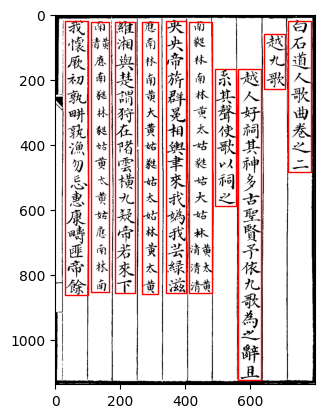

In [98]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

book = Book([
    Juan(
        information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
        children=[
            Section(
                information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
                children=[
                    SongOfYue(edition_directory + "./json/03_yuejiuge/016_dishunchudiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/017_wangyuwudiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/018_yuewangyuediao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/019_yuexiangceshangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/020_xiangwanggupingdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/021_taozhishenshuangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/022_caoeshucediao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/023_pangjiangjungaopingdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/024_jingzhongzhongguanshangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/025_caixiaozizhongguanbanzhandiao.json"),
                    #Table("./json/03_yuejiuge/gujinpufa.json"),
                    #Description("./json/03_yuejiuge/zhezifa.json"),
                ]),
        ]),
])

print(book.to_tei())

image_path = os.path.join(edition_directory, "images", book.physical_lines[0].page())
plt.figure()
plt.imshow(Image.open(image_path), cmap="gray")
for line in book.physical_lines[:10]:
    (x, y), (x2, y2) = line.coordinates()
    rect = patches.Rectangle((x, y), x2-x, y2-y, linewidth=1, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

In [161]:

book = Book([
    Juan(
        information_file=edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json",
        children=[
            Section(
                information_file=edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json",
                children=[
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/01_shangdiming.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/02_hezhibiao.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/03_huaihaizhuo.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/04_yuanzhishang.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/05_huangweichang.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/06_shushansui.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/07_shiyupei.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/08_wangzhongshan.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/09_dazairen.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/10_ougegui.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/11_fagongji.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/12_dilinyong.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/13_weisiye.json"),
                    Song(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/14_yanjingfu.json"),
                ]),
            Section(
                information_file=edition_directory + "./json/02_qinquyishou/qinquyishou.json",
                children=[
                    #Description("./json/02_qinquyishou/ceshangdiao.json"),
                    #Table("./json/02_qinquyishou/diaoxianfa.json"),
                    Song(edition_directory + "./json/02_qinquyishou/015_guyuan.json"),
                ])
        ]),
    Juan(
        information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
        children=[
            Section(
                information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
                children=[
                    SongOfYue(edition_directory + "./json/03_yuejiuge/016_dishunchudiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/017_wangyuwudiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/018_yuewangyuediao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/019_yuexiangceshangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/020_xiangwanggupingdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/021_taozhishenshuangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/022_caoeshucediao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/023_pangjiangjungaopingdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/024_jingzhongzhongguanshangdiao.json"),
                    SongOfYue(edition_directory + "./json/03_yuejiuge/025_caixiaozizhongguanbanzhandiao.json"),
                    #Table("./json/03_yuejiuge/gujinpufa.json"),
                    #Description("./json/03_yuejiuge/zhezifa.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/04_ling/ling.json",
        children=[
            Section(
                information_file=edition_directory + "./json/04_ling/ling.json",
                children=[
                    Song(edition_directory + "./json/04_ling/026_xiaochongshanling.json"),
                    Song(edition_directory + "./json/04_ling/027_jiangmeiyin.json"),
                    Song(edition_directory + "./json/04_ling/028_moshanxi.json"),
                    Song(edition_directory + "./json/04_ling/029_yingshengraohonglou.json"),
                    Song(edition_directory + "./json/04_ling/030_geximeiling.json"),
                    Song(edition_directory + "./json/04_ling/031_ruanlanggui.json"),
                    Song(edition_directory + "./json/04_ling/032_ruanlanggui.json"),
                    Song(edition_directory + "./json/04_ling/033_haoshijin.json"),
                    Song(edition_directory + "./json/04_ling/034_dianjiangchun.json"),
                    Song(edition_directory + "./json/04_ling/035_dianjiangchun.json"),
                    Song(edition_directory + "./json/04_ling/036_yumeiren.json"),
                    Song(edition_directory + "./json/04_ling/037_yumeiren.json"),
                    Song(edition_directory + "./json/04_ling/038_yiwangsun.json"),
                    Song(edition_directory + "./json/04_ling/039_shaonianyou.json"),
                    Song(edition_directory + "./json/04_ling/040_zhegutian.json"),
                    Song(edition_directory + "./json/04_ling/041_zhegutian.json"),
                    Song(edition_directory + "./json/04_ling/042_zhegutian.json"),
                    Song(edition_directory + "./json/04_ling/043_zhegutian.json"),
                    Song(edition_directory + "./json/04_ling/044_zhegutian.json"),
                    Song(edition_directory + "./json/04_ling/045_zhegutian.json"),
                    Song(edition_directory + "./json/04_ling/046_zhegutian.json"),
                    Song(edition_directory + "./json/04_ling/047_yexingchuan.json"),
                    Song(edition_directory + "./json/04_ling/048_xinghuatianying.json"),
                    Song(edition_directory + "./json/04_ling/049_zuiyinshangxiaopin.json"),
                    Song(edition_directory + "./json/04_ling/050_yumeiling.json"),
                    Song(edition_directory + "./json/04_ling/051_tashaxing.json"),
                    Song(edition_directory + "./json/04_ling/052_suzhongqing.json"),
                    Song(edition_directory + "./json/04_ling/053_huanxisha.json"),
                    Song(edition_directory + "./json/04_ling/054_huanxisha.json"),
                    Song(edition_directory + "./json/04_ling/055_huanxisha.json"),
                    Song(edition_directory + "./json/04_ling/056_huanxisha.json"),
                    Song(edition_directory + "./json/04_ling/057_huanxisha.json"),
                    Song(edition_directory + "./json/04_ling/058_huanxisha.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/05_man/man.json",
        children=[
            Section(
                information_file=edition_directory + "./json/05_man/man.json",
                children=[
                    Song(edition_directory + "./json/05_man/059_nishangzhongxu.json"),
                    Song(edition_directory + "./json/05_man/060_qinggongchun.json"),
                    Song(edition_directory + "./json/05_man/061_qitianle.json"),
                    Song(edition_directory + "./json/05_man/062_manjianghong.json"),
                    Song(edition_directory + "./json/05_man/063_yiehong.json"),
                    Song(edition_directory + "./json/05_man/064_niannujiao.json"),
                    Song(edition_directory + "./json/05_man/065_niannujiao.json"),
                    Song(edition_directory + "./json/05_man/066_meiwu.json"),
                    Song(edition_directory + "./json/05_man/067_yuexiadi.json"),
                    Song(edition_directory + "./json/05_man/068_qingboyin.json"),
                    Song(edition_directory + "./json/05_man/069_faquxianxianyin.json"),
                    Song(edition_directory + "./json/05_man/070_pipaxian.json"),
                    Song(edition_directory + "./json/05_man/071_linglongsifan.json"),
                    Song(edition_directory + "./json/05_man/072_cefan.json"),
                    Song(edition_directory + "./json/05_man/073_shuilongyin.json"),
                    Song(edition_directory + "./json/05_man/074_tanchunman.json"),
                    Song(edition_directory + "./json/05_man/075_bagui.json"),
                    Song(edition_directory + "./json/05_man/076_jielianhuan.json"),
                    Song(edition_directory + "./json/05_man/077_xiyingqianman.json"),
                    Song(edition_directory + "./json/05_man/078_moyuer.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
        children=[
            Section(
                information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
                children=[
                    Song(edition_directory + "./json/06_ziduqu/079_yangzhouman.json"),
                    Song(edition_directory + "./json/06_ziduqu/080_changtingyuanman.json"),
                    Song(edition_directory + "./json/06_ziduqu/081_danhuangliu.json"),
                    Song(edition_directory + "./json/06_ziduqu/082_shihuxian.json"),
                    Song(edition_directory + "./json/06_ziduqu/083_anxiang.json"),
                    Song(edition_directory + "./json/06_ziduqu/084_shuying.json"),
                    Song(edition_directory + "./json/06_ziduqu/085_xihongyi.json"),
                    Song(edition_directory + "./json/06_ziduqu/086_jueshao.json"),
                    Song(edition_directory + "./json/06_ziduqu/087_zhishao.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/07_zizhiqu/zizhiqu.json",
        children=[
            Section(
                information_file=edition_directory + "./json/07_zizhiqu/zizhiqu.json",
                children=[
                    Song(edition_directory + "./json/07_zizhiqu/088_quixiaoyin.json"),
                    Song(edition_directory + "./json/07_zizhiqu/089_qiliangfan.json"),
                    Song(edition_directory + "./json/07_zizhiqu/090_cuilouyin.json"),
                    Song(edition_directory + "./json/07_zizhiqu/091_xiangyue.json"),
                    #Song(edition_directory + "./json/07_zizhiqu/qingyuanhuiyao.json"),
                ]),
        ]),
    Juan(
        information_file=edition_directory + "./json/08_bieji/bieji.json",
        children=[
            Section(
                information_file=edition_directory + "./json/08_bieji/bieji.json",
                children=[
                    Song(edition_directory + "./json/08_bieji/092_xiaochongshanling.json"),
                    Song(edition_directory + "./json/08_bieji/093_niannujiao.json"),
                    Song(edition_directory + "./json/08_bieji/094_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/095_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/096_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/097_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/098_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/099_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/100_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/101_busuanzi.json"),
                    Song(edition_directory + "./json/08_bieji/102_dongxiange.json"),
                    Song(edition_directory + "./json/08_bieji/103_moshanxi.json"),
                    Song(edition_directory + "./json/08_bieji/104_yongyule.json"),
                    Song(edition_directory + "./json/08_bieji/105_yumeiren.json"),
                    Song(edition_directory + "./json/08_bieji/106_yongyule.json"),
                    Song(edition_directory + "./json/08_bieji/107_shuidiaogetou.json"),
                    Song(edition_directory + "./json/08_bieji/108_hangongchun.json"),
                    Song(edition_directory + "./json/08_bieji/109_hangongchun.json"),
                ]),
        ]),])

平聲十畆梅花作雪飛冷香下擕手多時兩年不到斷橋西
嘉泰壬辰至日刻于東巖之讀書堂雲間錢希武五湖舊約問經年底事長負清景暝入西山漸喚我一
廢月上海雲沈鷗去吳波逈行過西冷有一枝竹暗人家
西今廢蘚幹石斜妨玉蕋松低覆日暮㝠㝠一見來略比年時
馬城在都城西北梅屏甚見珍愛家在馬城西曾賦梅屏雪梅雪相𠔥不見花月影玲瓏
山後梅皆阜陵時所種緑萼更横枝多少梅花樣惆悵西邨一塢春開過無人
越之昌源古梅妙天下𧰼筆帶香題龍笛吟春咽楊桺嬌癡未覺愁花管人離
章及之御苑接湖波松下春風細雲緑


In [100]:
print(book[1][0].to_tei())

<div type="section"><head><lb/>越九歌</head><p ana="preface"><lb/>越人好祠其神多古聖賢予依九歌為之辭且<lb/>系其聲使歌以祠之</p><div type="song"><lg><l><lb/><notatedMusic/><lb/>央央帝旂群冕相輿聿來我媯我芸緑滋</l><l><lb/><notatedMusic/><lb/>維湘與楚謂狩在陼雲横九疑帝若來下</l><l><lb/><notatedMusic/><lb/>我懷厥初孰畊孰漁勿忘惠康疇匪帝餘</l><l><lb/><notatedMusic/><lb/>博碩于爼維錯于豆瑶灑玉離侑此桂酒</l></lg><trailer><lb/>右<title>帝舜楚調</title></trailer></div><div type="song"><lg><l><lb/><notatedMusic/><lb/>登崇邱懷美功窋䆛在雲其濛</l><l><lb/><notatedMusic/><lb/>享維德輯萬國轍轇轕蹇時宅</l><l><lb/><notatedMusic/><lb/>珠為橇玉為車報我則腆不當厥拘</l><l><lb/><notatedMusic/><lb/>王斾返風偃偃山鳥呼觚棱晚豐予諶菲可薦</l></lg><trailer><lb/>右<title>王禹吳調</title><space quantity="2" unit="chars"/><seg type="mode">夾鍾宫</seg></trailer></div><div type="song"><lg><l><lb/><notatedMusic/><lb/>雲蒼凉山嶻嶭瞻靈旗闖越絶</l><l><lb/><notatedMusic/><lb/>故宫凄凄生緑蕪謀臣安在空五湖酹君君母西入吳</l><l><lb/><notatedMusic/><lb/>洪濤卷地龍工呼函堅操剡何睢盱彼茁竹箭楊梅朱</l><l><lb/><notatedMusic/><lb/>壺觴有酎盤有魚千春萬春勿忘此故都</l></lg><trailer><lb/>右<title>越王越調</title><space quantity="2" unit="chars"/><seg type="mode">無射商</

In [172]:
def transform_juan_to_tei(juan_path: str):
    tei_string = ""
    all_jsons = sorted(os.listdir(juan_path))
    
    pieces = [json for json in all_jsons if json[0].isnumeric()]
    others = [json for json in all_jsons if not json[0].isnumeric()]
    
    for other in others:
        tei_string += transform_juan_description_to_tei(os.path.join(juan, other))
            
    for piece in pieces:
        tei_string += transform_piece_to_tei(os.path.join(juan, piece))
            
    return f'<div type="juan">{tei_string}</div>'

In [ ]:
def transform_book_to_tei(juan_division: list[str], other: str):
    tei_string = ""
    
    # Table of Contents
    # Juan 1: 01_shengsongnaogeguchuiqushisishou, 02_qinquyishou
    tei_string 
    # Juan 2: 03_yuejiuge
    # Juan 3: 04_ling
    # Juan 4: 05_man
    # Juan 5: 06_ziduqu
    # Juan 6: 07_zizhiqu
    # Appendix: 08_bieji
        
    return f'<div type="book">{tei_string}</div>'
    #return f'<div type="book" style="writing-mode: vertical-rl">{tei_string}</div>'

In [208]:
base_directory = "./json"

all_files = []
for folder in sorted(next(os.walk(base_directory))[1]):
    everything = sorted(os.listdir(os.path.join(base_directory, folder)))
    everything = [os.path.join(base_directory, folder, e) for e in everything]
    pieces = [e for e in everything if e[0].isnumeric()]
    other = [e for e in everything if not e[0].isnumeric()]
    
    all_files += other
    all_files += pieces
    
print(all_files)


['./json/01_shengsongnaogeguchuiqushisishou/01_shangdiming.json', './json/01_shengsongnaogeguchuiqushisishou/02_hezhibiao.json', './json/01_shengsongnaogeguchuiqushisishou/03_huaihaizhuo.json', './json/01_shengsongnaogeguchuiqushisishou/04_yuanzhishang.json', './json/01_shengsongnaogeguchuiqushisishou/05_huangweichang.json', './json/01_shengsongnaogeguchuiqushisishou/06_shushansui.json', './json/01_shengsongnaogeguchuiqushisishou/07_shiyupei.json', './json/01_shengsongnaogeguchuiqushisishou/08_wangzhongshan.json', './json/01_shengsongnaogeguchuiqushisishou/09_dazairen.json', './json/01_shengsongnaogeguchuiqushisishou/10_ougegui.json', './json/01_shengsongnaogeguchuiqushisishou/11_fagongji.json', './json/01_shengsongnaogeguchuiqushisishou/12_dilinyong.json', './json/01_shengsongnaogeguchuiqushisishou/13_weisiye.json', './json/01_shengsongnaogeguchuiqushisishou/14_yanjingfu.json', './json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json', './json/02_qinquyishou/015